In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
import glob
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img

In [ ]:
train_dir = "./chest-xray-pneumonia/chest_xray/chest_xray/train"
test_dir = "./chest-xray-pneumonia/chest_xray/chest_xray/test"
val_dir = "./chest-xray-pneumonia/chest_xray/chest_xray/val"


## Basic Data information.

In [3]:
print("Train set:")
print("-"*60)
num_pneumonia = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
num_normal = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
print(f"PNEUMONIA={num_pneumonia}")
print(f"NORMAL={num_normal}")

print("\nTest set:")
print('-'*60)
print(f"PNEUMONIA={len(os.listdir(os.path.join(test_dir, 'PNEUMONIA')))}")
print(f"NORMAL={len(os.listdir(os.path.join(test_dir, 'NORMAL')))}")

print("\nValidation set")
print('-'*60)
print(f"PNEUMONIA={len(os.listdir(os.path.join(val_dir, 'PNEUMONIA')))}")
print(f"NORMAL={len(os.listdir(os.path.join(val_dir, 'NORMAL')))}")

pneumonia = os.listdir("./chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA")
pneumonia_dir = "./chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA"

Train set:
------------------------------------------------------------
PNEUMONIA=3875
NORMAL=1341

Test set:
------------------------------------------------------------
PNEUMONIA=390
NORMAL=234

Validation set
------------------------------------------------------------
PNEUMONIA=8
NORMAL=8


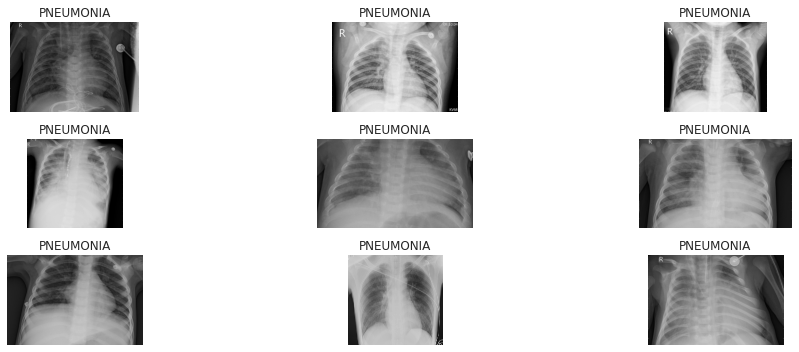

In [4]:
plt.figure(figsize=(15, 5))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(pneumonia_dir, pneumonia[i]))
    plt.title("PNEUMONIA")
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    

plt.tight_layout()

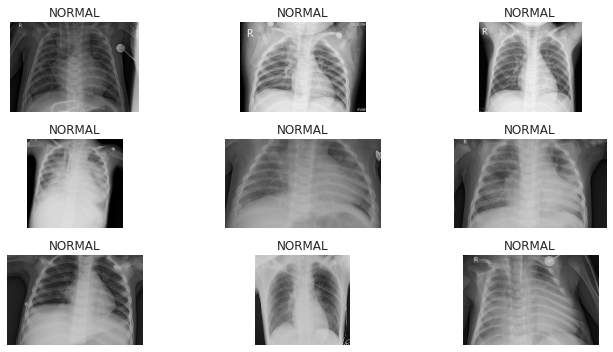

In [5]:
normal = os.listdir("./chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL")
normal_dir = "./chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL"

plt.figure(figsize=(10, 5))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(pneumonia_dir, pneumonia[i]))
    plt.title("NORMAL")
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
plt.tight_layout()


In [6]:
import glob

pneumonia_train = glob.glob(train_dir+"/PNEUMONIA/*.jpeg")
normal_train = glob.glob(train_dir+"/NORMAL/*.jpeg")

In [7]:
data = pd.DataFrame(np.concatenate([[0]*len(normal_train) , [1]*len(pneumonia_train)]),columns=["class"])

Labels are: `0 - NORMAL || 1 - PNEUMONIA`

In [8]:
data.head()

,class
0,0
1,0
2,0
3,0
4,0


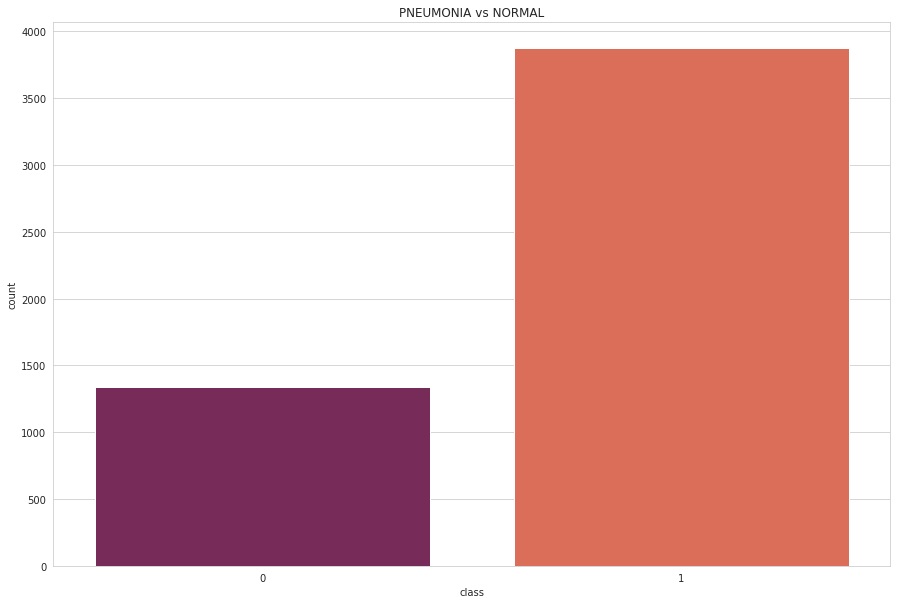

In [9]:
plt.figure(figsize=(15,10))
sns.countplot(data['class'],data=data,palette='rocket')
plt.title('PNEUMONIA vs NORMAL')
plt.show()

## Data Augmentation

In [10]:
img_Datagen = ImageDataGenerator(
        rescale = 1/255,
        shear_range=10,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.5,2.0],
        width_shift_range = 0.2,
        rotation_range=20,
        fill_mode = 'nearest'
)
val_Datagen = ImageDataGenerator(
        rescale = 1/255
)

In [11]:

train = img_Datagen.flow_from_directory(train_dir,
                                       batch_size=32,
                                       class_mode='binary',
#                                        target_size=(224,224,3))
                                       )

validation = val_Datagen.flow_from_directory(val_dir,
                                              batch_size=2,
                                              class_mode='binary',
#                                               target_size=(224,224,3))
                                            )

test = val_Datagen.flow_from_directory(test_dir,
                                       batch_size=2,
                                       class_mode='binary',
#                                        target_size=(224/,224,3))
                                      )

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [12]:
img, label = next(train)

# Defining the model

In [ ]:
vgg_model = tf.keras.applications.VGG19(
    weights='imagenet',
    include_top = False,
#     input_shape = (224,224,3)
)

for layer in vgg_model.layers:
    layer.trainable=False
    
x = vgg_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128,activation='relu')(x)
# output layer
predictions = tf.keras.layers.Dense(1,activation='sigmoid')(x)

model = tf.keras.Model(inputs=vgg_model.input, outputs=predictions)

# to avoid overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10)
lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',patience=8)

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [14]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, None, None, 3)]   0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, None, None, 64)    1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, None, None, 64)    36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, None, None, 64)    0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, None, None, 128)   73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, None, None, 128)   147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, None, None, 128)   0     

In [ ]:
history = model.fit(train,epochs=30, 
                    validation_data=validation,
                     steps_per_epoch=100,
                    callbacks=[early_stopping,lr],
                    batch_size=32)

# Evaluating the VGG19

In [16]:
# Evaluating the model on train and test
score = model.evaluate(train)

print("Train Loss: ", score[0])
print("Train Accuracy: ", score[1])

163/163 [==============================] - 133s 814ms/step - loss: 0.2278 - accuracy: 0.9036
Train Loss:  0.22778460383415222
Train Accuracy:  0.9035659432411194


In [17]:
# Test data
score = model.evaluate(test)

print("Test Loss: ", score[0])
print("Test Accuracy: ", score[1])

312/312 [==============================] - 10s 32ms/step - loss: 0.3409 - accuracy: 0.8494
Test Loss:  0.3409405052661896
Test Accuracy:  0.8493589758872986


Text(0.5, 1.0, 'Accuracy Evolution')

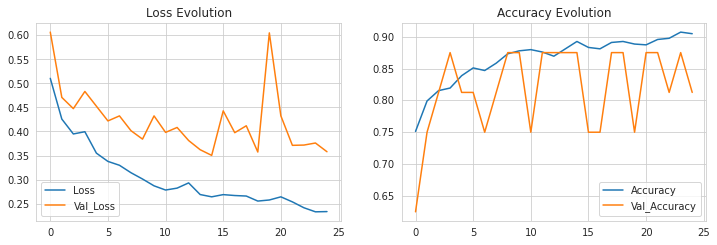

In [18]:
plt.figure(figsize=(12, 8))
plt.title('EVALUATION OF VGG19')

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val_Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

# ResNet50V2

In [21]:
resnet_model = tf.keras.applications.ResNet50V2(
    weights='imagenet',
    include_top = False,
    input_shape = (224,224,3)
)

for layer in resnet_model.layers:
    layer.trainable=False
    
x = resnet_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128,activation='relu')(x)
# output layer
predictions = tf.keras.layers.Dense(1,activation='sigmoid')(x)

model2 = tf.keras.Model(inputs=resnet_model.input, outputs=predictions)

# to avoid overfitting
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=6)

# Compiling the model
model2.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

94683136/94668760 [==============================] - 0s 0us/step


In [22]:
history = model2.fit(train,epochs=30, 
                    validation_data=validation,
                     steps_per_epoch=100,
                    callbacks=[early_stopping,lr],
                    batch_size=32)

Epoch 1/30
100/100 [==============================] - 84s 813ms/step - loss: 0.2886 - accuracy: 0.8747 - val_loss: 0.2041 - val_accuracy: 0.9375
Epoch 2/30
100/100 [==============================] - 81s 804ms/step - loss: 0.2065 - accuracy: 0.9162 - val_loss: 0.1855 - val_accuracy: 0.9375
Epoch 3/30
100/100 [==============================] - 81s 805ms/step - loss: 0.1890 - accuracy: 0.9219 - val_loss: 0.2109 - val_accuracy: 0.9375
Epoch 4/30
100/100 [==============================] - 81s 807ms/step - loss: 0.1914 - accuracy: 0.9275 - val_loss: 0.1319 - val_accuracy: 0.9375
Epoch 5/30
100/100 [==============================] - 81s 812ms/step - loss: 0.1586 - accuracy: 0.9319 - val_loss: 0.3253 - val_accuracy: 0.8750
Epoch 6/30
100/100 [==============================] - 81s 810ms/step - loss: 0.1752 - accuracy: 0.9294 - val_loss: 0.2822 - val_accuracy: 0.8750
Epoch 7/30
100/100 [==============================] - 82s 815ms/step - loss: 0.1631 - accuracy: 0.9413 - val_loss: 0.2019 - val_ac

In [23]:
# Evaluating the model on train and test
score = model2.evaluate(train)

print("Train Loss: ", score[0])
print("Train Accuracy: ", score[1])

score = model2.evaluate(test)
print("\nTest loss: ", score[0])
print("Test Accuracy: ", score[1])

163/163 [==============================] - 133s 817ms/step - loss: 0.1176 - accuracy: 0.9528
Train Loss:  0.1175629198551178
Train Accuracy:  0.9528374075889587
312/312 [==============================] - 9s 27ms/step - loss: 0.1961 - accuracy: 0.9199

Test loss:  0.19611118733882904
Test Accuracy:  0.9198718070983887


Text(0.5, 1.0, 'Accuracy Evolution')

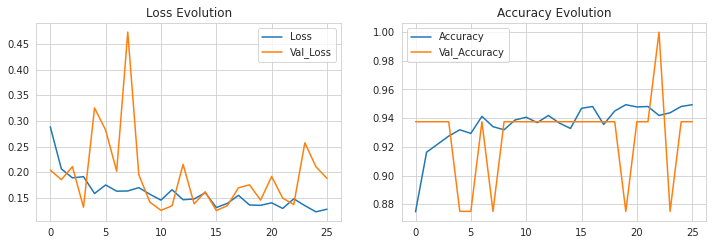

In [24]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val_Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

# MobileNetV2

In [28]:
mobilenet_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top = False,
#     input_shape = (224,224,3)
)

for layer in mobilenet_model.layers:
    layer.trainable=False
    
x = mobilenet_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128,activation='relu')(x)
# output layer
predictions = tf.keras.layers.Dense(1,activation='sigmoid')(x)

model3 = tf.keras.Model(inputs=mobilenet_model.input, outputs=predictions)

# to avoid overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10)
lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',patience=8)

# Compiling the model
model3.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [29]:
history = model3.fit(train,epochs=30, 
                    validation_data=validation,
                     steps_per_epoch=100,
                    callbacks=[early_stopping,lr],
                    batch_size=32)

Epoch 1/30
100/100 [==============================] - 85s 829ms/step - loss: 0.3325 - accuracy: 0.8497 - val_loss: 0.3119 - val_accuracy: 0.8125
Epoch 2/30
100/100 [==============================] - 81s 806ms/step - loss: 0.2155 - accuracy: 0.9131 - val_loss: 0.3485 - val_accuracy: 0.8750
Epoch 3/30
100/100 [==============================] - 81s 815ms/step - loss: 0.2125 - accuracy: 0.9119 - val_loss: 0.3473 - val_accuracy: 0.7500
Epoch 4/30
100/100 [==============================] - 81s 806ms/step - loss: 0.1998 - accuracy: 0.9134 - val_loss: 0.2689 - val_accuracy: 0.8750
Epoch 5/30
100/100 [==============================] - 81s 806ms/step - loss: 0.1892 - accuracy: 0.9256 - val_loss: 0.5604 - val_accuracy: 0.7500
Epoch 6/30
100/100 [==============================] - 80s 798ms/step - loss: 0.1864 - accuracy: 0.9200 - val_loss: 0.3061 - val_accuracy: 0.8750
Epoch 7/30
100/100 [==============================] - 81s 806ms/step - loss: 0.1817 - accuracy: 0.9284 - val_loss: 0.3321 - val_ac

In [31]:
# Evaluating the model on train and test
score = model3.evaluate(train)

print("Train Loss: ", score[0])
print("Train Accuracy: ", score[1])

score = model3.evaluate(test)
print("\nTest loss: ", score[0])
print("Test Accuracy: ", score[1])

163/163 [==============================] - 131s 804ms/step - loss: 0.1560 - accuracy: 0.9360
Train Loss:  0.155979186296463
Train Accuracy:  0.9359662532806396
312/312 [==============================] - 8s 24ms/step - loss: 0.2610 - accuracy: 0.8974

Test loss:  0.2609941363334656
Test Accuracy:  0.8974359035491943


Text(0.5, 1.0, 'Accuracy Evolution')

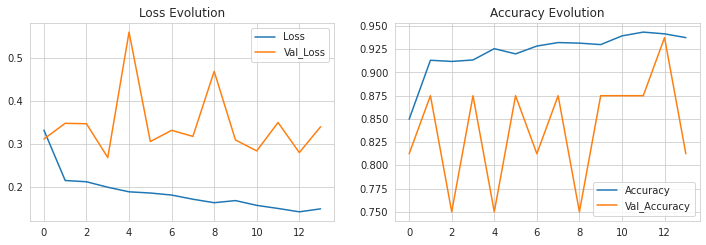

In [32]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val_Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

In [34]:
# Saving these 3 models
model.save('vgg19.h5')

In [35]:
model2.save('resnet50v2.h5')
model3.save('mobilenetv2.h5')

# Fine Tuning

In [39]:
resnet_model.trainable = True
vgg_model.trainable = True
mobilenet_model.trainable = True

In [49]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(vgg_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in vgg_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  22


In [54]:
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, None, None,  0                                            
__________________________________________________________________________________________________
Conv1 (Conv2D)                  (None, None, None, 3 864         input_3[0][0]                    
__________________________________________________________________________________________________
bn_Conv1 (BatchNormalization)   (None, None, None, 3 128         Conv1[0][0]                      
__________________________________________________________________________________________________
Conv1_relu (ReLU)               (None, None, None, 3 0           bn_Conv1[0][0]                   
____________________________________________________________________________________________

In [55]:
# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [56]:
len(model.trainable_variables)

4

In [57]:
fine_tune_epochs = 10
epochs_on_raw_model = 30

total_epochs =  epochs_on_raw_model + fine_tune_epochs

history_fine =model.fit(train,epochs=total_epochs, 
                    validation_data=validation,
                    steps_per_epoch=100,
                    callbacks=[early_stopping,lr],
                    batch_size=32)

Epoch 1/40
100/100 [==============================] - 84s 815ms/step - loss: 0.2676 - accuracy: 0.8841 - val_loss: 0.3038 - val_accuracy: 0.8750
Epoch 2/40
100/100 [==============================] - 79s 792ms/step - loss: 0.2124 - accuracy: 0.9119 - val_loss: 0.2853 - val_accuracy: 0.8750
Epoch 3/40
100/100 [==============================] - 80s 794ms/step - loss: 0.2043 - accuracy: 0.9203 - val_loss: 0.3925 - val_accuracy: 0.7500
Epoch 4/40
100/100 [==============================] - 80s 798ms/step - loss: 0.2035 - accuracy: 0.9103 - val_loss: 0.4484 - val_accuracy: 0.7500
Epoch 5/40
100/100 [==============================] - 80s 802ms/step - loss: 0.1837 - accuracy: 0.9262 - val_loss: 0.4395 - val_accuracy: 0.7500
Epoch 6/40
100/100 [==============================] - 80s 800ms/step - loss: 0.1896 - accuracy: 0.9216 - val_loss: 0.6475 - val_accuracy: 0.7500
Epoch 7/40
100/100 [==============================] - 80s 799ms/step - loss: 0.1801 - accuracy: 0.9278 - val_loss: 0.3247 - val_ac

# Evaluating the Fine Tune model

In [58]:
# Evaluating the model on train and test
score = model.evaluate(train)

print("Train Loss: ", score[0])
print("Train Accuracy: ", score[1])

score = model.evaluate(test)
print("\nTest loss: ", score[0])
print("Test Accuracy: ", score[1])

163/163 [==============================] - 129s 790ms/step - loss: 0.1321 - accuracy: 0.9494
Train Loss:  0.13205191493034363
Train Accuracy:  0.949386477470398
312/312 [==============================] - 7s 24ms/step - loss: 0.2830 - accuracy: 0.8942

Test loss:  0.282981276512146
Test Accuracy:  0.8942307829856873


Text(0.5, 1.0, 'Accuracy Evolution')

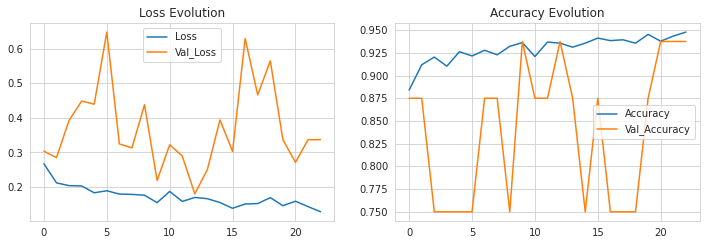

In [60]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history_fine.history['loss'], label='Loss')
plt.plot(history_fine.history['val_loss'], label='Val_Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(2, 2, 2)
plt.plot(history_fine.history['accuracy'], label='Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

In [61]:
# Fine tuning the resnet model


# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(resnet_model.layers))


fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in resnet_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  190


In [62]:
model2.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 230, 230, 3)  0           input_2[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 112, 112, 64) 9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
pool1_pad (ZeroPadding2D)       (None, 114, 114, 64) 0           conv1_conv[0][0]                 
____________________________________________________________________________________________

In [63]:
# Compiling the model
model2.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [65]:
len(model2.trainable_variables)

86

In [66]:
fine_tune_epochs = 10
epochs_on_raw_model = 30

total_epochs =  epochs_on_raw_model + fine_tune_epochs

history_fine =model2.fit(train,epochs=total_epochs, 
                    validation_data=validation,
                    steps_per_epoch=100,
                    callbacks=[early_stopping,lr],
                    batch_size=32)

Epoch 1/40
100/100 [==============================] - 87s 830ms/step - loss: 0.2790 - accuracy: 0.8916 - val_loss: 1.0652 - val_accuracy: 0.9375
Epoch 2/40
100/100 [==============================] - 82s 819ms/step - loss: 0.1732 - accuracy: 0.9334 - val_loss: 0.3025 - val_accuracy: 0.8750
Epoch 3/40
100/100 [==============================] - 86s 854ms/step - loss: 0.1718 - accuracy: 0.9337 - val_loss: 0.4586 - val_accuracy: 0.8750
Epoch 4/40
100/100 [==============================] - 83s 833ms/step - loss: 0.1626 - accuracy: 0.9344 - val_loss: 0.3363 - val_accuracy: 0.8750
Epoch 5/40
100/100 [==============================] - 84s 835ms/step - loss: 0.1306 - accuracy: 0.9509 - val_loss: 0.1480 - val_accuracy: 0.8750
Epoch 6/40
100/100 [==============================] - 83s 834ms/step - loss: 0.1306 - accuracy: 0.9484 - val_loss: 0.2449 - val_accuracy: 0.8750
Epoch 7/40
100/100 [==============================] - 85s 851ms/step - loss: 0.1307 - accuracy: 0.9481 - val_loss: 0.3151 - val_ac

In [73]:
# Evaluating the model on train and test
score = model2.evaluate(train)

print("Train Loss: ", score[0])
print("Train Accuracy: ", score[1])

score = model2.evaluate(test)
print("\nTest loss: ", score[0])
print("Test Accuracy: ", score[1])

163/163 [==============================] - 146s 896ms/step - loss: 0.0606 - accuracy: 0.9778
Train Loss:  0.060622863471508026
Train Accuracy:  0.9777607321739197
312/312 [==============================] - 9s 28ms/step - loss: 0.1629 - accuracy: 0.9343

Test loss:  0.1629357635974884
Test Accuracy:  0.9342948794364929


In [68]:
# Fine tuning the mobilenetv2

# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(mobilenet_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in mobilenet_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


In [69]:
# Compiling the model
model3.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [70]:
len(model3.trainable_variables)

58

In [71]:
fine_tune_epochs = 10
epochs_on_raw_model = 30

total_epochs =  epochs_on_raw_model + fine_tune_epochs

history_fine =model3.fit(train,epochs=total_epochs, 
                    validation_data=validation,
                    steps_per_epoch=100,
                    callbacks=[early_stopping,lr],
                    batch_size=32)

Epoch 1/40
100/100 [==============================] - 84s 809ms/step - loss: 0.2632 - accuracy: 0.9003 - val_loss: 31.7052 - val_accuracy: 0.5000
Epoch 2/40
100/100 [==============================] - 80s 799ms/step - loss: 0.1720 - accuracy: 0.9287 - val_loss: 16.6139 - val_accuracy: 0.5000
Epoch 3/40
100/100 [==============================] - 80s 801ms/step - loss: 0.1422 - accuracy: 0.9466 - val_loss: 7.5683 - val_accuracy: 0.5000
Epoch 4/40
100/100 [==============================] - 79s 790ms/step - loss: 0.1279 - accuracy: 0.9484 - val_loss: 8.3575 - val_accuracy: 0.5000
Epoch 5/40
100/100 [==============================] - 81s 813ms/step - loss: 0.0998 - accuracy: 0.9663 - val_loss: 6.9664 - val_accuracy: 0.5000
Epoch 6/40
100/100 [==============================] - 81s 802ms/step - loss: 0.1221 - accuracy: 0.9519 - val_loss: 5.1655 - val_accuracy: 0.5000
Epoch 7/40
100/100 [==============================] - 80s 802ms/step - loss: 0.1125 - accuracy: 0.9566 - val_loss: 0.0389 - val_

In [74]:
# Evaluating the model on train and test
score = model3.evaluate(train)

print("Train Loss: ", score[0])
print("Train Accuracy: ", score[1])

score = model3.evaluate(test)
print("\nTest loss: ", score[0])
print("Test Accuracy: ", score[1])

163/163 [==============================] - 145s 887ms/step - loss: 0.6960 - accuracy: 0.8779
Train Loss:  0.6959661245346069
Train Accuracy:  0.8778757452964783
312/312 [==============================] - 8s 26ms/step - loss: 1.7427 - accuracy: 0.7532

Test loss:  1.74266517162323
Test Accuracy:  0.7532051205635071


Text(0.5, 1.0, 'Accuracy Evolution')

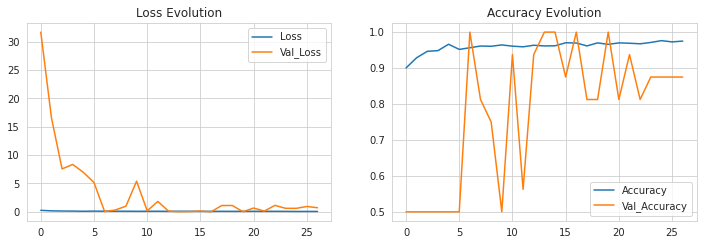

In [75]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history_fine.history['loss'], label='Loss')
plt.plot(history_fine.history['val_loss'], label='Val_Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(2, 2, 2)
plt.plot(history_fine.history['accuracy'], label='Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Val_Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

In [76]:
# Saving the fine tuned model
model.save('tuned_vgg19.h5')
model2.save('tuned_resnet.h5')
model3.save('tuned_mobilenet.h5')

# Model evaluation

In [78]:
# Loading the saved version of Tuned-ResNet50V2
final_model = tf.keras.models.load_model('tuned_resnet.h5')

In [79]:
y_pred = final_model.predict(test)

In [80]:
final_model.evaluate(test)

312/312 [==============================] - 10s 26ms/step - loss: 0.1629 - accuracy: 0.9343


[0.16293570399284363, 0.9342948794364929]